## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem. 


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [1]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn.functional as F
import kagglehub
import os, shutil
import splitfolders
import matplotlib.pyplot as plt

from datasets import load_dataset, get_dataset_split_names
from transformers import AutoTokenizer, AutoModel,CLIPTokenizer, pipeline, DistilBertForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, CLIPModel, CLIPProcessor, CLIPTokenizer
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader
from tqdm import tqdm
from torchvision import datasets
from peft import LoraConfig, TaskType, get_peft_model
from pathlib import Path
from omegaconf import OmegaConf
from sklearn.svm import SVC

/home/filippo/Scrivania/DLA/lab2/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
splits = get_dataset_split_names('cornell-movie-review-data/rotten_tomatoes')
ds_dict = {split: load_dataset('cornell-movie-review-data/rotten_tomatoes', split=split) for split in splits}

ds_train = ds_dict['train']
ds_validation = ds_dict['validation']
ds_test = ds_dict['test']

### Exploratory Data Analysis ###

For each of the above subsets, I count the number of positive and negative reviews:

In [3]:
positive_count, negative_count = 0, 0

for row in range(len(np.random.permutation(ds_train))):
    if ds_train[row]['label']:
        positive_count += 1
    else:
        negative_count += 1

print(f'Training set - Positive: {positive_count}, Negative: {negative_count}\n')

positive_count, negative_count = 0, 0

for row in range(len(np.random.permutation(ds_validation))):
    if ds_validation[row]['label']:
        positive_count += 1
    else:
        negative_count += 1

print(f'Validation set - Positive: {positive_count}, Negative: {negative_count}\n')

positive_count, negative_count = 0, 0

for row in range(len(np.random.permutation(ds_test))):
    if ds_test[row]['label']:
        positive_count += 1
    else:
        negative_count += 1

print(f'Test set - Positive: {positive_count}, Negative: {negative_count}')

Training set - Positive: 4265, Negative: 4265

Validation set - Positive: 533, Negative: 533

Test set - Positive: 533, Negative: 533


The dataset is therefore perfectly balanced.


---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [4]:
model = AutoModel.from_pretrained('distilbert/distilbert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('distilbert/distilbert-base-uncased')

Nelle due celle successive, vedremo un esempio di codifica (tokenizzazione) e decodifica.

In [5]:
batch_sample = tokenizer(ds_train[:10]['text'], return_tensors='pt', padding=True)
print(batch_sample)

{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0],
        [  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
          1997,  1996,  7635,  1000, 11544,  2003,  2061,  4121,  2008,  1037,
          5930,  1997,  2616,  3685, 23613,  6235,  2522,  1011,  3213,  1013,
          2472,  2848,  4027,  1005,  1055,  4423,  4432,  1997,  1046,  1012,
          1054,  1012,  1054,  1012, 23602,  1005,  1055,  2690,  1011,  3011,
          1012,   102],
        [  101,  4621,  2021,  2205,  1011,  8915, 23267, 16012, 24330,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     

In [6]:
for i in range(10):
    print(tokenizer.decode(batch_sample['input_ids'][i]), "---", ds_train[i]['text'], "\n")

[CLS] the rock is destined to be the 21st century ' s new " conan " and that he ' s going to make a splash even greater than arnold schwarzenegger, jean - claud van damme or steven segal. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] --- the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal . 

[CLS] the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co - writer / director peter jackson ' s expanded vision of j. r. r. tolkien ' s middle - earth. [SEP] --- the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth . 

[CLS] effective but too - tepid biopic [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PA


---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [7]:
feature_extractor = pipeline('feature-extraction', model=model, tokenizer=tokenizer)
train_feats = feature_extractor(list(ds_train['text']), return_tensors='pt')
val_feats = feature_extractor(list(ds_validation['text']), return_tensors='pt')
test_feats = feature_extractor(list(ds_test['text']), return_tensors='pt')

Device set to use cuda:0


In [8]:
train_feats = torch.vstack([train_feat[0][0] for train_feat in train_feats])
val_feats = torch.vstack([val_feat[0][0] for val_feat in val_feats])
test_feats = torch.vstack([test_feat[0][0] for test_feat in test_feats])

In [9]:
train_classes = torch.tensor([train_cls for train_cls in ds_train['label']])
validation_classes = torch.tensor([val_cls for val_cls in ds_validation['label']])
test_classes = torch.tensor([test_cls for test_cls in ds_test['label']])

In [10]:
svc = SVC(kernel='linear')
svc.fit(train_feats, train_classes)

SVC(kernel='linear')

In [11]:
print(classification_report(svc.predict(val_feats), validation_classes))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82       566
           1       0.79      0.84      0.81       500

    accuracy                           0.82      1066
   macro avg       0.82      0.82      0.82      1066
weighted avg       0.82      0.82      0.82      1066



In [12]:
print(classification_report(svc.predict(test_feats), test_classes))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       551
           1       0.79      0.82      0.80       515

    accuracy                           0.81      1066
   macro avg       0.81      0.81      0.81      1066
weighted avg       0.81      0.81      0.81      1066



---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [13]:
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True)

In [14]:
tokenized_train = ds_train.map(preprocess_function, batched=True)
tokenized_validation = ds_validation.map(preprocess_function, batched=True)
tokenized_test = ds_test.map(preprocess_function, batched=True)


tokenized_train.set_format('pt', columns=['input_ids'], output_all_columns=True)
tokenized_validation.set_format('pt', columns=['input_ids'], output_all_columns=True)
tokenized_test.set_format('pt', columns=['input_ids'], output_all_columns=True)


---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [15]:
cls_model = DistilBertForSequenceClassification.from_pretrained('distilbert/distilbert-base-uncased', num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [17]:
training_args = TrainingArguments(
    output_dir='./output',
    learning_rate=1e-5,
    weight_decay=0.1,
    per_device_train_batch_size=512,
    per_device_eval_batch_size=512,
    lr_scheduler_type='linear',
    num_train_epochs=10,
    use_cpu=False,
    save_strategy='epoch',
    report_to='wandb',
    logging_strategy="steps",
    logging_steps=1,
    do_eval=True,
    eval_strategy='epoch',
    bf16=True,
    bf16_full_eval=True,
)

In [18]:
def compute_metrics(logits, labels):
    pred = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(pred, labels),
        'precision': precision_score(pred, labels),
        'recall': recall_score(pred, labels),
        'f1': f1_score(pred, labels),
    }

In [19]:
trainer = Trainer(
    model=cls_model,
    args=training_args,
    train_dataset=tokenized_train,
    data_collator=data_collator,
    eval_dataset=tokenized_validation,
)

In [20]:
trainer.train()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/filippo/.netrc.
wandb: Currently logged in as: filitaiti (filitaiti-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.635500,0.630447
2,0.482500,0.479605
3,0.409100,0.409512
4,0.312500,0.391912
5,0.337400,0.377823
6,0.344100,0.374425
7,0.266600,0.372802
8,0.339100,0.369129
9,0.277300,0.368606
10,0.273900,0.369208


TrainOutput(global_step=170, training_loss=0.38934943868833427, metrics={'train_runtime': 52.6735, 'train_samples_per_second': 1619.41, 'train_steps_per_second': 3.227, 'total_flos': 1412141795931936.0, 'train_loss': 0.38934943868833427, 'epoch': 10.0})

In [21]:
output = trainer.predict(tokenized_test)
compute_metrics(output.predictions, tokenized_test['label'])

{'accuracy': 0.8452157598499062,
 'precision': 0.8461538461538461,
 'recall': 0.8445692883895131,
 'f1': 0.845360824742268}

Grazie al fine-tuning, l'accuracy è migliorata di quasi 0.03 punti (**0.81** -> **0.837**)


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

**Why choose this exercise?** CLIP is probably the most widely used Vision-Language Model, and adapting it is a useful skill to master.

In [22]:
ft_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch16', dtype=torch.bfloat16) # Modello CLIP
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch16', dtype=torch.bfloat16) # Wrapper che contiene sia il tokenizer che il feature extractor delle immagini
tokenizer = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch16', dtype=torch.bfloat16) # Tokenizer per i testi

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [23]:
training_set = load_dataset('frgfm/imagenette', '320px', split='train')
validation_set = load_dataset('frgfm/imagenette', '320px', split='validation')

Using the latest cached version of the dataset since frgfm/imagenette couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration '320px' at /home/filippo/.cache/huggingface/datasets/frgfm___imagenette/320px/1.0.0/a8a496123b40fa739da2acf9b0dae339d30c7bae (last modified on Sat Apr 18 16:42:44 2026).
Using the latest cached version of the dataset since frgfm/imagenette couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration '320px' at /home/filippo/.cache/huggingface/datasets/frgfm___imagenette/320px/1.0.0/a8a496123b40fa739da2acf9b0dae339d30c7bae (last modified on Sat Apr 18 16:42:44 2026).


### Evaluate classification accuracy on ImageNet

In [24]:
labels_names = training_set.features['label'].names
images, labels = [], []

for element in tqdm(training_set):
    images.append(element['image'])
    labels.append(element['label'])

100%|██████████| 9469/9469 [00:03<00:00, 2551.38it/s]


In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

text_inputs = tokenizer([f'a photo of a {label}' for label in labels_names], return_tensors='pt', padding=True).to(device)

In [26]:
batch_size = 64
predictions = []
ft_model = ft_model.to(device)

for k in tqdm(range(0, len(images), batch_size)):
    k_end = min(k + batch_size, len(images))

    images_ = processor(images=images[k:k_end], return_tensors='pt')['pixel_values'].to(device)

    with torch.no_grad():
        image_embeddings = ft_model.get_image_features(pixel_values=images_)
        image_embeddings = F.normalize(image_embeddings, dim=-1).to(torch.float32).cpu().numpy()

        label_embeddings = ft_model.get_text_features(input_ids=text_inputs['input_ids'], attention_mask=text_inputs['attention_mask'])
        label_embeddings = F.normalize(label_embeddings, dim=-1).to(torch.float32).cpu().numpy()

    scores = np.dot(image_embeddings, label_embeddings.T)
    predictions.extend(np.argmax(scores, axis=-1).tolist())

accuracy = accuracy_score(labels, predictions)
print(f'Image-Net classification accuracy: {accuracy*100:.3f}%')

ft_model = ft_model.to('cpu')

100%|██████████| 148/148 [00:22<00:00,  6.54it/s]


Image-Net classification accuracy: 99.356%


The resulting accuracy is nearly perfect.

### Fine-tuning (FULL) on sketches images

In [27]:
path = kagglehub.dataset_download("dhananjayapaliwal/fulldataset")
print("Path to dataset files:", path)

Path to dataset files: /home/filippo/.cache/kagglehub/datasets/dhananjayapaliwal/fulldataset/versions/3


The following code snippet is needed to perform the splits in:

1. Training set
2. Validation set
3. Test set

In [28]:
if not Path('dataset_split').exists():

    base_path = os.path.join(path, 'temp_extraction', '256x256', 'splitted_sketches')
    output_path = '../lab2/dataset'
    os.makedirs(output_path, exist_ok=True)

    for tx_folder in os.listdir(base_path):
        tx_path = os.path.join(base_path, tx_folder)


        for category in os.listdir(tx_path):
            cat_src = os.path.join(tx_path, category)

            for file in os.listdir(cat_src):
                src = os.path.join(cat_src, file)
                cat_dest = os.path.join(output_path, file)
                os.makedirs(cat_dest, exist_ok=True)

                for image in os.listdir(src):
                    src_image = os.path.join(src, image)
                    dst_image = os.path.join(cat_dest, image)
                    shutil.copy2(src_image, dst_image)

    splitfolders.ratio(output_path, output='dataset_split', seed=1302, ratio=(0.7, 0.15, 0.15))

else:
    print("Dataset already exists and is split, skipping file operations.")


Dataset already exists and is split, skipping file operations.


In [29]:
training_set = datasets.ImageFolder('../lab2/dataset_split/train')
validation_set = datasets.ImageFolder('../lab2/dataset_split/val')
test_set = datasets.ImageFolder('../lab2/dataset_split/test')

labels_names = training_set.classes

Instantiation of the **LoRA** model:

In [30]:
for p in ft_model.parameters():
    p.requires_grad = False


lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules= ['q_proj', 'v_proj'], 
    lora_dropout= 0.05,
    bias='none',
    modules_to_save=[],
    task_type=TaskType.FEATURE_EXTRACTION
)

lora_model = get_peft_model(ft_model, lora_config)
lora_model.print_trainable_parameters()

trainable params: 491,520 || all params: 150,112,257 || trainable%: 0.3274


In [31]:
def collate_fn(batch_examples):
    images, labels = zip(*batch_examples)

    processed_batch_examples = processor(
        images = list(images),
        return_tensors='pt',
        padding=True,
    )
    return processed_batch_examples, torch.tensor(labels)

In [32]:
config = OmegaConf.create({
    'batch_size':64,
    'lr': 3e-5,
    'weight_decay': 0.01,
    'num_epochs': 15,
    'num_classes': 10,
    'num_workers_dl': 8
})

In [33]:
train_dl = DataLoader(training_set, batch_size=config.batch_size, num_workers=config.num_workers_dl, shuffle=True, collate_fn=collate_fn)
validation_dl = DataLoader(validation_set, batch_size=config.batch_size, num_workers=config.num_workers_dl, shuffle=False, collate_fn=collate_fn)
test_dl = DataLoader(test_set, batch_size=config.batch_size, num_workers=config.num_workers_dl, shuffle=False, collate_fn=collate_fn)

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
texts = tokenizer([f'a sketch of a {label}' for label in labels_names], return_tensors='pt', padding=True).to(device)

Evaluation of model's performance on the new dataset BEFORE fine-tuning:

In [35]:
ft_model.eval()
ft_model = ft_model.to(device)
predictions_, all_labels = [], [] 

with torch.no_grad():
    text_embeddings = ft_model.get_text_features(input_ids=texts['input_ids'], attention_mask=texts['attention_mask'])
    text_embeddings = F.normalize(text_embeddings.to(torch.float32), dim=-1).cpu().numpy()

with torch.no_grad():  
    for element, labels in tqdm(test_dl):
        pixel_values = element['pixel_values'].to(device, dtype=torch.bfloat16)

        image_embeds = ft_model.get_image_features(pixel_values=pixel_values)
        image_embeds = F.normalize(image_embeds.to(torch.float32), dim=-1).cpu().numpy()

        scores = np.dot(image_embeds, text_embeddings.T)
        predictions_.extend(np.argmax(scores, axis=-1).tolist())
        all_labels.extend(labels.tolist())

pre_ft_accuracy = accuracy_score(all_labels, predictions_)
print(f'PRE-Fine-tuning accuracy: {pre_ft_accuracy*100:.3f}%')
ft_model = ft_model.to('cpu')

100%|██████████| 179/179 [00:15<00:00, 11.39it/s]


PRE-Fine-tuning accuracy: 65.612%


The resulting accuracy is quite low.

Here is the fine-tuning:

Evaluating: 100%|██████████| 176/176 [00:15<00:00, 11.15it/s]


Accuracy at epoch 1: 83.498%
AVG Train Loss: 0.7838, AVG Validation Loss: 4.1532


Evaluating: 100%|██████████| 176/176 [00:14<00:00, 12.29it/s]


Accuracy at epoch 2: 85.567%
AVG Train Loss: 0.6304, AVG Validation Loss: 4.1191


Evaluating: 100%|██████████| 176/176 [00:14<00:00, 12.12it/s]


...

Accuracy at epoch 13: 89.013%
AVG Train Loss: 0.4739, AVG Validation Loss: 4.0576


Evaluating: 100%|██████████| 176/176 [00:15<00:00, 11.48it/s]


Accuracy at epoch 14: 89.075%
AVG Train Loss: 0.4655, AVG Validation Loss: 4.0591


Evaluating: 100%|██████████| 176/176 [00:15<00:00, 11.46it/s]


Accuracy at epoch 15: 89.058%
AVG Train Loss: 0.4658, AVG Validation Loss: 4.0603


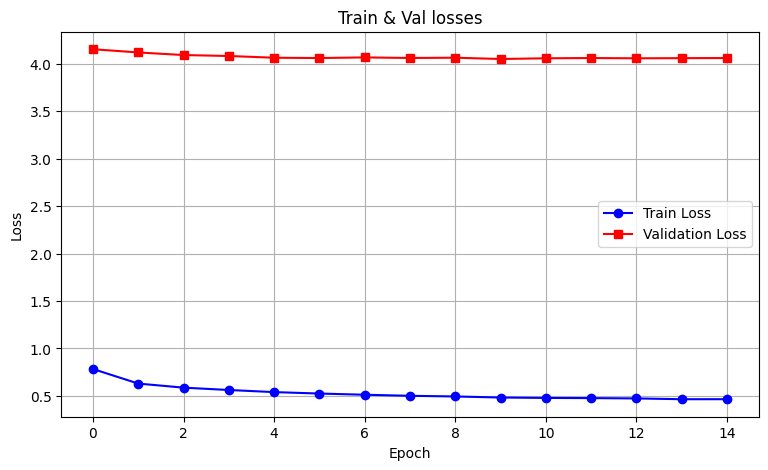

In [36]:
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, lora_model.parameters()), lr=config.lr, weight_decay=config.weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, config.num_epochs)
lora_model = lora_model.to(device)

all_input_ids = texts['input_ids'].to(device)
all_attention_mask = texts['attention_mask'].to(device)

avg_train_losses, avg_val_losses = [], []
for epoch in range(config.num_epochs):
    lora_model.train()
    total_train_loss = 0
    total_validation_loss = 0
    for element, labels in tqdm(train_dl, desc=f'Training - Epoch {epoch}'):
        pixel_values = element['pixel_values'].to(device, dtype=torch.bfloat16)
        labels = labels.to(device)

        batch_input_ids = all_input_ids[labels]
        batch_attention_mask = all_attention_mask[labels]

        image_embeds = lora_model.get_image_features(pixel_values=pixel_values)
        image_embeds = F.normalize(image_embeds, dim=-1).to(torch.float32)

        text_embeds = lora_model.get_text_features(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
        text_embeds = F.normalize(text_embeds, dim=-1).to(torch.float32)

        logit_scale = lora_model.logit_scale.exp().to(torch.float32)
        image_logits = logit_scale * image_embeds @ text_embeds.T
        text_logits = logit_scale * text_embeds @ image_embeds.T

        mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()

        targets = mask / mask.sum(dim=1, keepdim=True)
        targets = targets.to(device)

        image_train_loss = F.cross_entropy(image_logits, targets)
        text_train_loss = F.cross_entropy(text_logits, targets)
        train_loss = (image_train_loss + text_train_loss) /2
        
        optimizer.zero_grad()
        train_loss.backward()
        total_train_loss += train_loss.item()
        optimizer.step()

    lora_model.eval()
    predictions_, all_labels = [], []

    with torch.no_grad():
        global_text_embeds = lora_model.get_text_features(input_ids=all_input_ids, attention_mask=all_attention_mask)
        global_text_embeds = F.normalize(global_text_embeds, dim=-1)
        global_text_embeds = global_text_embeds.float()

        for element, labels in tqdm(validation_dl, desc='Evaluating'): 
            pixel_values = element['pixel_values'].to(device, dtype=torch.bfloat16)
            labels = labels.to(device)

            batch_input_ids = all_input_ids[labels]
            batch_attention_mask = all_attention_mask[labels]
            
            image_embeds = lora_model.get_image_features(pixel_values=pixel_values)
            image_embeds = F.normalize(image_embeds, dim=-1).float()

            text_embeds = lora_model.get_text_features(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
            text_embeds = F.normalize(text_embeds, dim=-1).float()

            logit_scale = lora_model.logit_scale.exp().to(torch.float32)
            image_logits = logit_scale * image_embeds @ text_embeds.T
            text_logits = logit_scale * text_embeds @ image_embeds.T

            mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()

            targets = mask / mask.sum(dim=1, keepdim=True)
            targets = targets.to(device)

            image_validation_loss = F.cross_entropy(image_logits, targets)
            text_validation_loss = F.cross_entropy(text_logits, targets)
            validation_loss = (image_validation_loss + text_validation_loss) /2
            total_validation_loss += validation_loss.cpu().item()

            scores = image_embeds @ global_text_embeds.T  
            predictions_.extend(scores.argmax(dim=-1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())


    new_accuracy = accuracy_score(all_labels, predictions_)
    avg_train_losses.append(total_train_loss / len(train_dl))
    avg_val_losses.append(total_validation_loss / len(validation_dl))
    print(f'Accuracy at epoch {epoch + 1}: {new_accuracy * 100:.3f}%')
    print(f'AVG Train Loss: {avg_train_losses[epoch]:.4f}, AVG Validation Loss: {avg_val_losses[epoch]:.4f}')
    scheduler.step()



plt.figure(figsize=(9, 5))
plt.plot(avg_train_losses, color='blue', marker='o', label='Train Loss')
plt.plot(avg_val_losses, color='red', marker='s', label='Validation Loss')
plt.title('Train & Val losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [37]:
lora_model.eval()
predictions_, all_labels = [], [] 
with torch.no_grad():  
    for element, labels in tqdm(test_dl):
        pixel_values = element['pixel_values'].to(device, dtype=torch.bfloat16)

        batch_input_ids = all_input_ids[labels]
        batch_attention_mask = all_attention_mask[labels]

        image_embeds = lora_model.get_image_features(pixel_values=pixel_values)
        image_embeds = F.normalize(image_embeds, dim=-1).float()

        scores = image_embeds @ global_text_embeds.T  
        predictions_.extend(scores.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

post_ft_accuracy = accuracy_score(all_labels, predictions_)
print(f'POST-Fine-tuning accuracy: {post_ft_accuracy*100:.3f}%')

100%|██████████| 179/179 [00:15<00:00, 11.79it/s]

POST-Fine-tuning accuracy: 88.351%


The final result shows that accuracy has improved significantly: **65.5%** → **88.3%**